In [1]:
from correlation_stability import run_stability_analysis
import scanpy as sc
from run_dgcna_correlation import run_dgcna_analysis
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:

adata=sc.read_loom('Integrated_betas.loom') 
adata.obs_names=adata.obs.obs_names
adata.var_names=adata.var.gene_name



C:\Users\Leo\anaconda3\Lib\functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
C:\Users\Leo\anaconda3\Lib\functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [3]:
adata=adata[adata.obs.Disease=='normal'].copy()

import numpy as np

np.random.seed(0)  # optional, for reproducibility
n = adata.n_obs
groups = np.array(['A'] * (n // 2) + ['B'] * (n - n // 2))
np.random.shuffle(groups)

adata.obs['Group'] = groups

In [4]:
sel_genes=pd.read_excel("sel_genes.xlsx")
ndcg_genes=sel_genes.Gene_name.unique()
glyco=sel_genes[sel_genes.Module=='(6) Glycolysis'].Gene_name.values

In [5]:

results = run_dgcna_analysis(
    adata, 
    genes=ndcg_genes,  # optional: subset to specific genes
    disease_col='Group',
    t2d_value='B',
    ctrl_value='A',
    n_bootstrap=512,
    threshold=0.975
)


Using 664 / 671 specified genes

=== Step 1: Computing LMM residuals (per condition) ===
Cells: 228, donors: 8, genes: 664
Cells: 228, donors: 8, genes: 664

=== Step 2: Building differential network ===
T2D cells: 228, Control cells: 228

=== Step 3: Bootstrap filtering ===


Random donor groups (with replacement): 100%|████████████████████████████████████████| 512/512 [01:09<00:00,  7.41it/s]

Significant edges: 38273 / 220116 (17.4%)


In [6]:
results.keys()


dict_keys(['residuals', 'obs', 'corr_ctrl', 'corr_t2d', 'diff_net', 'filtered_net', 'mask'])

In [7]:
'''
# Access results
results['filtered_net']  # Bootstrap-filtered differential network
results['corr_t2d']      # T2D correlation matrix
results['corr_ctrl']     # Control correlation matrix
results['diff_net']      # Raw differential network (T2D - Ctrl)
results['p_values']      # Bootstrap significance
'''

"\n# Access results\nresults['filtered_net']  # Bootstrap-filtered differential network\nresults['corr_t2d']      # T2D correlation matrix\nresults['corr_ctrl']     # Control correlation matrix\nresults['diff_net']      # Raw differential network (T2D - Ctrl)\nresults['p_values']      # Bootstrap significance\n"

<Axes: xlabel='gene_name', ylabel='gene_name'>

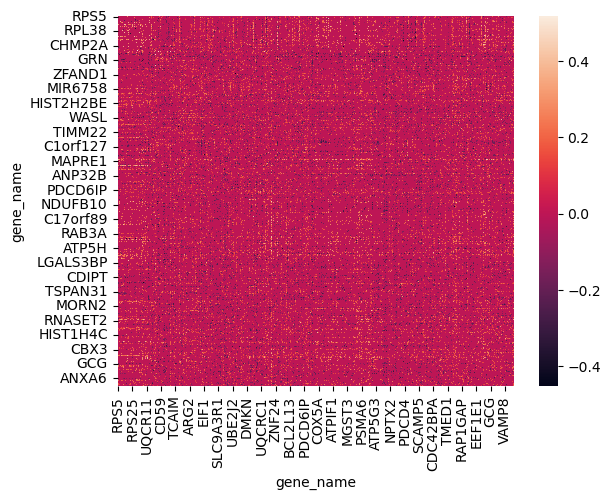

In [8]:
sns.heatmap(results['filtered_net'])

In [9]:
corr=results['filtered_net'].copy()

In [10]:
logfc_df = pd.read_csv("Integrated_logFC.csv", index_col=0)


In [11]:
# Assuming:
# - corr: pd.DataFrame (genes x genes) - differential correlation matrix (Δr = T2D - Ctrl)
# - logfc_df: pd.DataFrame with gene names as index and 'logFC' column

# Get upper triangle indices (avoid duplicates and diagonal)
genes = corr.index.tolist()
n = len(genes)

rows = []
for i in range(n):
    for j in range(i+1, n):
        g1, g2 = genes[i], genes[j]
        r_t2d =  results['corr_t2d'].iloc[i, j]
        r_ctrl =  results['corr_ctrl'].iloc[i, j]
        delta_r = results['filtered_net'].iloc[i, j]
        
        # Get |logFC| for each gene
        lfc1 = abs(logfc_df.loc[g1, 'logFC']) if g1 in logfc_df.index else np.nan
        lfc2 = abs(logfc_df.loc[g2, 'logFC']) if g2 in logfc_df.index else np.nan
        
        rows.append({
            'gene1': g1,
            'gene2': g2,
            'r_t2d': r_t2d,
            'r_ctrl': r_ctrl,
            'delta_r': delta_r,
            'abs_delta_r': abs(delta_r),
            'max_logFC': max(np.abs(lfc1), np.abs(lfc2)),
            'min_logFC': min(np.abs(lfc1), np.abs(lfc2)),
            'mean_logFC': (lfc1 + lfc2) / 2,
        })

edge_df = pd.DataFrame(rows).dropna()

In [12]:
#edge_df.to_csv('Edges_data.csv')

In [13]:
edge_df

,gene1,gene2,r_t2d,r_ctrl,delta_r,abs_delta_r,max_logFC,min_logFC,mean_logFC
0,RPS5,RPL11,0.517356,0.240572,0.000000,0.000000,0.185737,0.173918,0.179827
1,RPS5,RPL35A,0.395663,0.409010,0.000000,0.000000,0.317574,0.173918,0.245746
2,RPS5,GABARAP,0.502642,0.328082,0.000000,0.000000,0.173918,0.016436,0.095177
3,RPS5,DSTN,0.300454,0.394738,0.000000,0.000000,0.495335,0.173918,0.334626
4,RPS5,OAZ1,0.303997,0.263311,0.000000,0.000000,0.173918,0.098966,0.136442
...,...,...,...,...,...,...,...,...,...
220111,LYRM9,UBE2N,0.088647,0.183231,0.000000,0.000000,0.465786,0.371339,0.418562
220112,LYRM9,DARS2,0.119897,0.132871,0.000000,0.000000,0.465786,0.434768,0.450277
220113,ACADM,UBE2N,0.233371,0.079135,0.154237,0.154237,0.371339,0.282444,0.326891
220114,ACADM,DARS2,0.138812,0.101020,0.000000,0.000000,0.434768,0.282444,0.358606


In [14]:
# ── Summary statistics for dGCNA results ──
n_total = len(edge_df)
n_sig = (edge_df['abs_delta_r'] > 0).sum()
pct_sig = 100 * n_sig / n_total

print(f"Total gene pairs: {n_total}")
print(f"Significant edges (|Δr| > 0 after filtering): {n_sig} ({pct_sig:.1f}%)")

sig = edge_df[edge_df['abs_delta_r'] > 0]
nonsig = edge_df[edge_df['abs_delta_r'] == 0]

print(f"\n── Significant edges ──")
print(f"|Δr| median: {sig['abs_delta_r'].median():.3f}, mean: {sig['abs_delta_r'].mean():.3f}")
print(f"|Δr| range: [{sig['abs_delta_r'].min():.3f}, {sig['abs_delta_r'].max():.3f}]")
print(f"|Δr| Q1/Q3: {sig['abs_delta_r'].quantile(0.25):.3f} / {sig['abs_delta_r'].quantile(0.75):.3f}")

print(f"\nHyper-correlated in T2D (Δr > 0): {(sig['delta_r'] > 0).sum()} ({100*(sig['delta_r']>0).mean():.1f}%)")
print(f"De-correlated in T2D (Δr < 0):   {(sig['delta_r'] < 0).sum()} ({100*(sig['delta_r']<0).mean():.1f}%)")

print(f"\n── Correlation magnitudes ──")
print(f"|r_ctrl| median: {sig['r_ctrl'].abs().median():.3f}, mean: {sig['r_ctrl'].abs().mean():.3f}")
print(f"|r_t2d| median:  {sig['r_t2d'].abs().median():.3f}, mean: {sig['r_t2d'].abs().mean():.3f}")

# How many sig edges have weak correlations in BOTH conditions?
weak_both = ((sig['r_ctrl'].abs() < 0.2) & (sig['r_t2d'].abs() < 0.2)).sum()
print(f"\nSig edges with |r| < 0.2 in BOTH conditions: {weak_both} ({100*weak_both/len(sig):.1f}%)")

weak_either = ((sig['r_ctrl'].abs() < 0.1) | (sig['r_t2d'].abs() < 0.1)).sum()
print(f"Sig edges with |r| < 0.1 in at least one condition: {weak_either} ({100*weak_either/len(sig):.1f}%)")

# Number of unique genes involved in significant edges
sig_genes = set(sig['gene1']).union(set(sig['gene2']))
print(f"\nUnique genes in significant edges: {len(sig_genes)}")

Total gene pairs: 220116
Significant edges (|Δr| > 0 after filtering): 38273 (17.4%)

── Significant edges ──
|Δr| median: 0.160, mean: 0.167
|Δr| range: [0.027, 0.516]
|Δr| Q1/Q3: 0.127 / 0.199

Hyper-correlated in T2D (Δr > 0): 22124 (57.8%)
De-correlated in T2D (Δr < 0):   16149 (42.2%)

── Correlation magnitudes ──
|r_ctrl| median: 0.092, mean: 0.111
|r_t2d| median:  0.126, mean: 0.138

Sig edges with |r| < 0.2 in BOTH conditions: 22711 (59.3%)
Sig edges with |r| < 0.1 in at least one condition: 32176 (84.1%)

Unique genes in significant edges: 664


Total gene pairs: 220116
Significant edges (|Δr| > 0 after filtering): 38273 (17.4%)
|Δr| median: 0.160, mean: 0.167
|Δr| range: [0.027, 0.516]
Hyper (Δr>0): 22124 (57.8%)
De   (Δr<0): 16149 (42.2%)
|r_ctrl| median: 0.092
|r_t2d| median:  0.126
Sig edges with |r|<0.2 in BOTH: 22711 (59.3%)
Unique genes in sig edges: 664

Saved dgcna_summary.png/.pdf


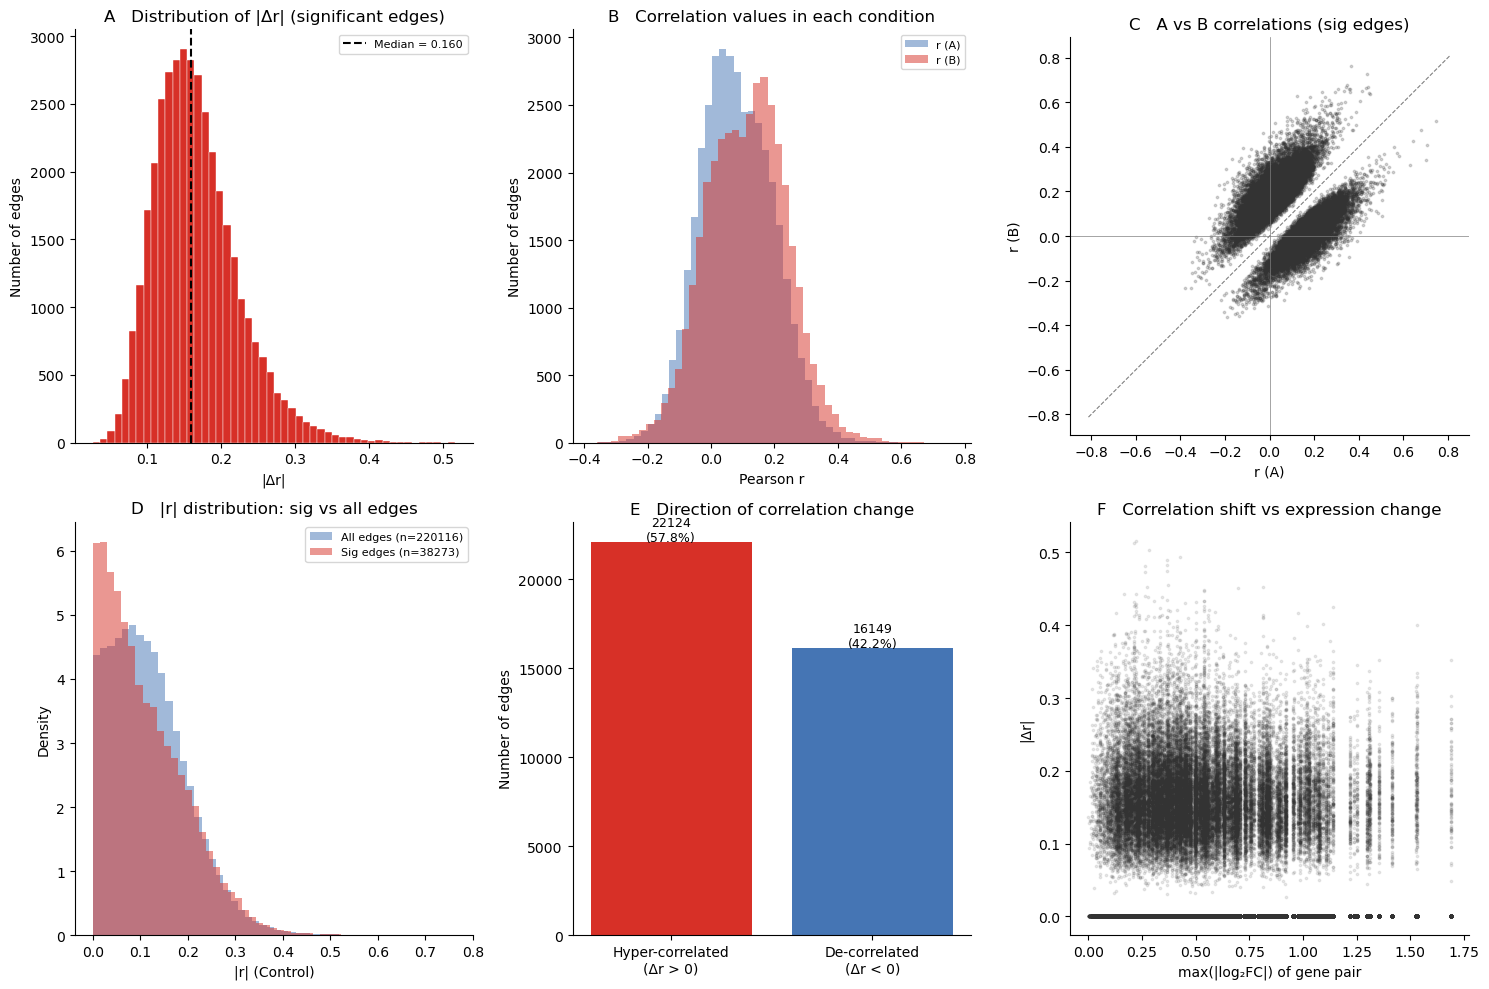

In [15]:
# ── Summary statistics + plots for dGCNA results ──

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

n_total = len(edge_df)
n_sig = (edge_df['abs_delta_r'] > 0).sum()
pct_sig = 100 * n_sig / n_total

sig = edge_df[edge_df['abs_delta_r'] > 0]
nonsig = edge_df[edge_df['abs_delta_r'] == 0]

print(f"Total gene pairs: {n_total}")
print(f"Significant edges (|Δr| > 0 after filtering): {n_sig} ({pct_sig:.1f}%)")
print(f"|Δr| median: {sig['abs_delta_r'].median():.3f}, mean: {sig['abs_delta_r'].mean():.3f}")
print(f"|Δr| range: [{sig['abs_delta_r'].min():.3f}, {sig['abs_delta_r'].max():.3f}]")
print(f"Hyper (Δr>0): {(sig['delta_r']>0).sum()} ({100*(sig['delta_r']>0).mean():.1f}%)")
print(f"De   (Δr<0): {(sig['delta_r']<0).sum()} ({100*(sig['delta_r']<0).mean():.1f}%)")
print(f"|r_ctrl| median: {sig['r_ctrl'].abs().median():.3f}")
print(f"|r_t2d| median:  {sig['r_t2d'].abs().median():.3f}")
weak_both = ((sig['r_ctrl'].abs() < 0.2) & (sig['r_t2d'].abs() < 0.2)).sum()
print(f"Sig edges with |r|<0.2 in BOTH: {weak_both} ({100*weak_both/len(sig):.1f}%)")
sig_genes = set(sig['gene1']).union(set(sig['gene2']))
print(f"Unique genes in sig edges: {len(sig_genes)}")

# ── Plots ──
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# A: Distribution of |Δr| for significant edges
ax = axes[0, 0]
ax.hist(sig['abs_delta_r'], bins=50, color='#d73027', edgecolor='white', linewidth=0.3)
ax.axvline(sig['abs_delta_r'].median(), color='black', lw=1.5, ls='--',
           label=f'Median = {sig["abs_delta_r"].median():.3f}')
ax.set_xlabel('|Δr|')
ax.set_ylabel('Number of edges')
ax.set_title('A   Distribution of |Δr| (significant edges)')
ax.legend(fontsize=8)
ax.spines[['top', 'right']].set_visible(False)

# B: Distribution of r_ctrl and r_t2d for significant edges
ax = axes[0, 1]
ax.hist(sig['r_ctrl'], bins=50, alpha=0.5, color='#4575b4', label='r (A)')
ax.hist(sig['r_t2d'], bins=50, alpha=0.5, color='#d73027', label='r (B)')
ax.set_xlabel('Pearson r')
ax.set_ylabel('Number of edges')
ax.set_title('B   Correlation values in each condition')
ax.legend(fontsize=8)
ax.spines[['top', 'right']].set_visible(False)

# C: Scatter r_ctrl vs r_t2d (significant edges)
ax = axes[0, 2]
ax.scatter(sig['r_ctrl'], sig['r_t2d'], alpha=0.2, s=3, color='#333333')
lim = max(abs(sig['r_ctrl']).max(), abs(sig['r_t2d']).max()) + 0.05
ax.plot([-lim, lim], [-lim, lim], 'k--', lw=0.8, alpha=0.5)
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)
ax.set_xlabel('r (A)')
ax.set_ylabel('r (B)')
ax.set_title('C   A vs B correlations (sig edges)')
ax.spines[['top', 'right']].set_visible(False)
ax.set_aspect('equal')

# D: Distribution of |r| in significant vs all edges
ax = axes[1, 0]
ax.hist(edge_df['r_ctrl'].abs(), bins=50, alpha=0.5, density=True,
        color='#4575b4', label=f'All edges (n={n_total})')
ax.hist(sig['r_ctrl'].abs(), bins=50, alpha=0.5, density=True,
        color='#d73027', label=f'Sig edges (n={n_sig})')
ax.set_xlabel('|r| (Control)')
ax.set_ylabel('Density')
ax.set_title('D   |r| distribution: sig vs all edges')
ax.legend(fontsize=8)
ax.spines[['top', 'right']].set_visible(False)

# E: Hyper vs de-correlation pie/bar
ax = axes[1, 1]
n_hyper = (sig['delta_r'] > 0).sum()
n_de = (sig['delta_r'] < 0).sum()
ax.bar(['Hyper-correlated\n(Δr > 0)', 'De-correlated\n(Δr < 0)'],
       [n_hyper, n_de], color=['#d73027', '#4575b4'])
ax.set_ylabel('Number of edges')
ax.set_title('E   Direction of correlation change')
ax.spines[['top', 'right']].set_visible(False)
for i, v in enumerate([n_hyper, n_de]):
    ax.text(i, v + 50, f'{v}\n({100*v/len(sig):.1f}%)', ha='center', fontsize=9)

# F: |Δr| vs max_logFC
ax = axes[1, 2]
ax.scatter(edge_df['max_logFC'], edge_df['abs_delta_r'], alpha=0.1, s=3, color='#333333')
ax.set_xlabel('max(|log₂FC|) of gene pair')
ax.set_ylabel('|Δr|')
ax.set_title('F   Correlation shift vs expression change')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('dgcna_Beta_Beta_summary.png', dpi=200, bbox_inches='tight')
plt.savefig('dgcna_Beta_Beta_summary.svg', bbox_inches='tight')
print("\nSaved dgcna_summary.png/.pdf")
plt.show()

In [16]:
results.keys()

dict_keys(['residuals', 'obs', 'corr_ctrl', 'corr_t2d', 'diff_net', 'filtered_net', 'mask'])

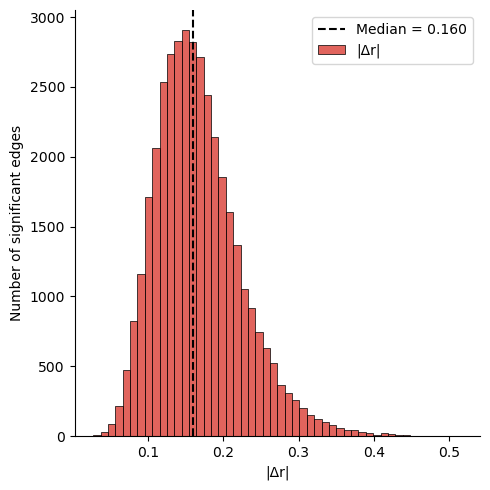

In [17]:
# Distribution of |Δr| for significant edges
fig, ax = plt.subplots(figsize=(5, 5))

sns.histplot(sig['abs_delta_r'], bins=50, color='#d73027', label='|Δr|', ax=ax)

ax.axvline(sig['abs_delta_r'].median(), color='black', lw=1.5, ls='--',
           label=f'Median = {sig["abs_delta_r"].median():.3f}')
ax.set_xlabel('|Δr|')
ax.set_ylabel('Number of significant edges')
ax.legend()
sns.despine()
plt.savefig('Figure3/delta_r.png')
plt.savefig('Figure3/delta_r.svg')
plt.tight_layout()

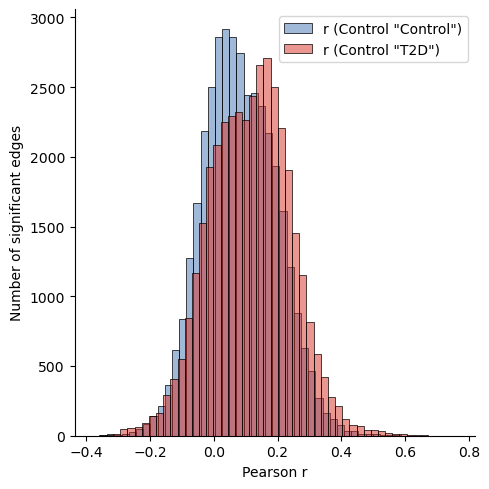

In [36]:
# Distribution of r_ctrl and r_t2d for significant edges

fig, ax = plt.subplots(figsize=(5, 5))

sns.histplot(sig['r_ctrl'], bins=50, alpha=0.5, color='#4575b4', label='r (Control "Control")', ax=ax)
sns.histplot(sig['r_t2d'], bins=50, alpha=0.5, color='#d73027', label='r (Control "T2D")', ax=ax)

ax.set_xlabel('Pearson r')
ax.set_ylabel('Number of significant edges')

ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig('Figure3/r_distribution.png')
plt.savefig('Figure3/r_distribution.svg')
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from itertools import combinations

# Keep healthy controls only
adata = adata[adata.obs.Disease == 'normal'].copy()

# Subject/donor ID
subject_col = 'Donor'  # <-- change if needed

subjects = np.array(adata.obs[subject_col].unique())

assert len(subjects) == 8, f"Expected 8 subjects, found {len(subjects)}"

summary = []

# 35 unique 4-vs-4 splits
# We only keep one of each A/B vs B/A pair
splits = [
    split for split in combinations(subjects, 4)
    if subjects[0] in split
]

print(f"Running {len(splits)} unique subject splits...")

for it, group_A_subjects in enumerate(splits):

    group_A_subjects = set(group_A_subjects)

    # Assign all cells from each subject to the same group
    adata.obs['Group'] = np.where(
        adata.obs[subject_col].isin(group_A_subjects),
        'A',
        'B'
    )

    # Run complete dGCNA pipeline
    results = run_dgcna_analysis(
        adata,
        genes=ndcg_genes,
        disease_col='Group',
        t2d_value='B',
        ctrl_value='A',
        n_bootstrap=512,
        threshold=0.975
    )

    corr = results['filtered_net']

    # Upper triangle only
    upper = np.triu(corr.values, k=1)
    sig_delta = np.abs(upper[upper != 0])

    # Total number of tested gene pairs
    n_genes = corr.shape[0]
    n_total = n_genes * (n_genes - 1) // 2

    summary.append({
        'iteration': it + 1,
        'group_A': ','.join(sorted(group_A_subjects)),
        'n_sig': len(sig_delta),
        'pct_sig': 100 * len(sig_delta) / n_total,
        'median_abs_delta_r': (
            np.median(sig_delta) if len(sig_delta) else np.nan
        )
    })

summary_df = pd.DataFrame(summary)

# Save results
summary_df.to_csv("dGCNA_control_control_all_splits.csv", index=False)


In [23]:

# Summary
print("\nSummary:")
print(f"Number of unique splits: {len(summary_df)}")
print(
    f"Significant edges — median: "
    f"{summary_df['n_sig'].median():.0f}"
)
print(
    f"Significant edges — range: "
    f"{summary_df['n_sig'].min():.0f}–"
    f"{summary_df['n_sig'].max():.0f}"
)
print(
    f"Percentage significant — median: "
    f"{summary_df['pct_sig'].median():.1f}%"
)
print(
    f"Percentage significant — range: "
    f"{summary_df['pct_sig'].min():.1f}–"
    f"{summary_df['pct_sig'].max():.1f}%"
)
print(
    f"Median |Δr| across splits: "
    f"{summary_df['median_abs_delta_r'].median():.3f}"
)



Summary:
Number of unique splits: 35
Significant edges — median: 8902
Significant edges — range: 5287–24613
Percentage significant — median: 4.0%
Percentage significant — range: 2.4–11.2%
Median |Δr| across splits: 0.223


C:\Users\Leo\AppData\Local\Temp\ipykernel_33296\1234536940.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


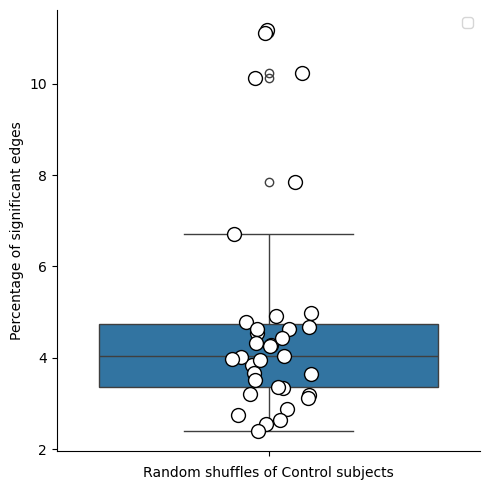

In [35]:
# Distribution of % of significant edges on random shuffles of control donors
fig, ax = plt.subplots(figsize=(5, 5))

sns.boxplot(summary_df, y='pct_sig')
sns.stripplot(summary_df, y='pct_sig',  linewidth=1, color='w', s=10, edgecolor='k')

ax.set_xlabel(f'Random shuffles of Control subjects')
ax.set_ylabel(f'Percentage of significant edges')
#ax.set_title(f'CTRL Sample ({largest_ctrl_donor}, n={largest_ctrl_n})\nr = {r_resid_ctrl:.3f}')
ax.spines[['top', 'right']].set_visible(False)
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig('Figure3/pct_significant.png')
plt.savefig('Figure3/pct_significant.svg')

In [24]:
summary_df

,iteration,group_A,n_sig,pct_sig,median_abs_delta_r
0,1,"Sample102,Sample103,Sample105,Sample106",10199,4.633466,0.217941
1,2,"Sample102,Sample103,Sample104,Sample105",22547,10.243235,0.242678
2,3,"HP1525901,Sample102,Sample103,Sample105",7368,3.347326,0.207140
3,4,"HP1711001,Sample102,Sample103,Sample105",9422,4.280470,0.226178
4,5,"HP1714601,Sample102,Sample103,Sample105",8479,3.852060,0.224494
5,6,"Sample102,Sample103,Sample104,Sample106",10973,4.985099,0.225285
6,7,"HP1525901,Sample102,Sample103,Sample106",10007,4.546239,0.222821
7,8,"HP1711001,Sample102,Sample103,Sample106",5629,2.557288,0.210895
8,9,"HP1714601,Sample102,Sample103,Sample106",5287,2.401915,0.207586
9,10,"HP1525901,Sample102,Sample103,Sample104",7031,3.194225,0.205695
